# Project Title

Customer Sentiment Analysis in various e-commerce platform


# Domain

This dataset belongs to the domain of Customer Analytics and Sentiment Analysis in the e-commerce industry.

# Objective

1. To analyze customer sentiment based on reviews and ratings across different platforms.
2. To identify factors affecting customer satisfaction such as response time and issue resolution.
3. To compare performance of different platforms (like Flipkart, Zepto, etc.) based on customer feedback.
4. To study customer behavior patterns based on age group, region, and purchase category.

# Outcome

Platforms with higher ratings show more positive customer sentiment. Faster response time improves overall customer satisfaction. Customer behavior and negative feedback are influenced by demographics and product categories.

# Dataset Information

Source: https://www.kaggle.com/datasets/kundanbedmutha/customer-sentiment-dataset


Year / Timeline: Data collected during 2024 to 2025

Dataset Description:

Customer sentiment and behavior analysis dataset from e-commerce platforms. The dataset contains 25,000 rows and 13 columns.

# Type of Analysis

**Descriptive Analysis:**
      Descriptive analysis is used to summarize and understand the basic features of the dataset by analyzing past data such as ratings, reviews, and customer details.

**Diagnostic Analysis:**
      Diagnostic analysis is used to identify the reasons behind certain outcomes by examining relationships between variables such as response time, ratings, and customer satisfaction.


# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection

Define the business problem and expected outcome

Choose dataset and explain its source, size, and features

Import libraries, load dataset

Dataset description (rows, columns, features)

Initial EDA (head, info, describe, shape, null checks, duplicate check)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/kathiravaganesan/My-Dataset/refs/heads/main/Customer_Sentiment.csv.csv"

df = pd.read_csv(url)

df.head()

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           25000 non-null  int64 
 1   gender                25000 non-null  object
 2   age_group             25000 non-null  object
 3   region                25000 non-null  object
 4   product_category      25000 non-null  object
 5   purchase_channel      25000 non-null  object
 6   platform              25000 non-null  object
 7   customer_rating       25000 non-null  int64 
 8   review_text           25000 non-null  object
 9   sentiment             25000 non-null  object
 10  response_time_hours   25000 non-null  int64 
 11  issue_resolved        25000 non-null  object
 12  complaint_registered  25000 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.5+ MB


In [ ]:
df.shape

(25000, 13)

In [ ]:
df.head()
df.tail()

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
24995,24996,female,36-45,south,beauty,online,lenskart,1,very disappointed with the quality.,negative,40,yes,yes
24996,24997,other,60+,central,automobile,online,flipkart,5,"amazing experience, highly recommend!",positive,25,yes,no
24997,24998,male,18-25,south,beauty,online,ajio,4,fast delivery and great packaging.,positive,9,yes,no
24998,24999,female,26-35,central,automobile,online,snapdeal,5,great value for money.,positive,65,no,no
24999,25000,male,46-60,central,travel,online,lenskart,3,"product is okay, nothing special.",neutral,67,no,no


In [ ]:
df.describe()

,customer_id,customer_rating,response_time_hours
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,3.002480,36.023480
std,7217.022701,1.404647,20.597941
min,1.000000,1.000000,1.000000
25%,6250.750000,2.000000,18.000000
50%,12500.500000,3.000000,36.000000
75%,18750.250000,4.000000,54.000000
max,25000.000000,5.000000,71.000000


In [ ]:
df.isnull().sum()

,0
customer_id,0
gender,0
age_group,0
region,0
product_category,0
purchase_channel,0
platform,0
customer_rating,0
review_text,0
sentiment,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
customer_id,25000
gender,3
age_group,5
region,5
product_category,9
purchase_channel,1
platform,20
customer_rating,5
review_text,15
sentiment,3


## Stage 2 – Data Cleaning and Pre-processing

Handle missing values (impute or drop)

Handle duplicates

Treat outliers if required

Check skewness and apply transformations

Convert data types if needed

Feature transformations (date parts, derived fields if required for analysis)

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
# This code is used to handle missing values in numeric columns of the dataset.
# First, it selects all numeric columns (int64, float64) using select_dtypes.Then, it loops through each numeric column and checks if there are any missing values.
# If missing values are found, they are filled using the median of that column.Median is used because it is less affected by outliers and gives a better central value.

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].mode().empty == False:
        df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# This code is used to handle missing values in categorical columns of the dataset.
# First, it selects all categorical columns (data type object) using select_dtypes.Then, it loops through each column and checks if the mode (most frequent value) is available.
# If the mode exists, the missing values in that column are filled with the mode.Mode is used because it replaces missing values with the most common category, maintaining data consistency.

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
# Removed Duplicate records to maintain data quality

In [ ]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [ ]:
# This code converts the date column into datetime format and safely handles invalid values.

In [ ]:
# Only numeric columns
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) |
          (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
# This code removes outliers using the IQR ( Interquartile Range ) method by filtering values outside the acceptable range.
# because outliers can affect analysis and give incorrect results, so removing them improves data quality and accuracy.

In [ ]:
import numpy as np
skewness = df[num_cols].skew()

# Apply only for highly skewed columns
for col in num_cols:
    if skewness[col] > 1 or skewness[col] < -1:
        df[col] = np.log1p(df[col])

In [ ]:
# This code identifies skewed columns and applies log transformation to normalize the data distribution.
# because highly skewed data can affect analysis and model performance, so transformation helps to normalize the data distribution.

In [ ]:
# Example only if columns exist
if 'likes' in df.columns and 'impressions' in df.columns:
    df['engagement_ratio'] = df['likes'] / df['impressions']

In [ ]:
# This code creates a new feature called engagement ratio to measure user engagement based on likes and impressions.
# because engagement ratio helps measure user interaction efficiency and gives better insight than raw likes or impressions alone.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           25000 non-null  int64 
 1   gender                25000 non-null  object
 2   age_group             25000 non-null  object
 3   region                25000 non-null  object
 4   product_category      25000 non-null  object
 5   purchase_channel      25000 non-null  object
 6   platform              25000 non-null  object
 7   customer_rating       25000 non-null  int64 
 8   review_text           25000 non-null  object
 9   sentiment             25000 non-null  object
 10  response_time_hours   25000 non-null  int64 
 11  issue_resolved        25000 non-null  object
 12  complaint_registered  25000 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.5+ MB


,customer_id,customer_rating,response_time_hours
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,3.002480,36.023480
std,7217.022701,1.404647,20.597941
min,1.000000,1.000000,1.000000
25%,6250.750000,2.000000,18.000000
50%,12500.500000,3.000000,36.000000
75%,18750.250000,4.000000,54.000000
max,25000.000000,5.000000,71.000000


In [ ]:
# df.info() gives structure of data, df.describe() gives statistical summary.

## Stage 3 – EDA and Visualizations

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

Interpretation MUST with every visualization

Focus on business story not just charts

Each chart must be in seperate cells.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/kathiravaganesan/My-Dataset/refs/heads/main/Customer_Sentiment.csv.csv")
df.head()

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no


In [ ]:
# This code is used because we need to load the dataset and import necessary libraries to perform data analysis and visualization.

In [ ]:
# Clean column names (remove spaces + lowercase)
df.columns = df.columns.str.strip().str.lower()

# Check columns
print(df.columns)

# Access likes column safely
if 'likes' in df.columns:
    print(df['likes'].head())
else:
    print("likes column not found")

Index(['customer_id', 'gender', 'age_group', 'region', 'product_category',
       'purchase_channel', 'platform', 'customer_rating', 'review_text',
       'sentiment', 'response_time_hours', 'issue_resolved',
       'complaint_registered'],
      dtype='object')
likes column not found


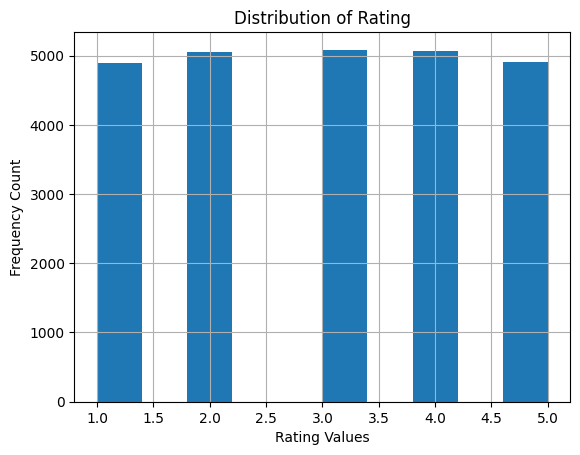

In [ ]:
# Histogram

import matplotlib.pyplot as plt

df['customer_rating'].hist()
plt.title("Distribution of Rating")
plt.xlabel("Rating Values")
plt.ylabel("Frequency Count")
plt.show()

In [ ]:
# This histogram visualizes the distribution of customer ratings across the dataset.

# From the plot, it is observed that ratings are spread across different values, showing how frequently each rating occurs. The shape of the histogram indicates whether the ratings are concentrated in a particular range or evenly distributed.

# The features used in this chart are customer_rating.

# This indicates the overall pattern of customer satisfaction, helping to identify whether most customers give high ratings or if there is significant variation in their feedback.

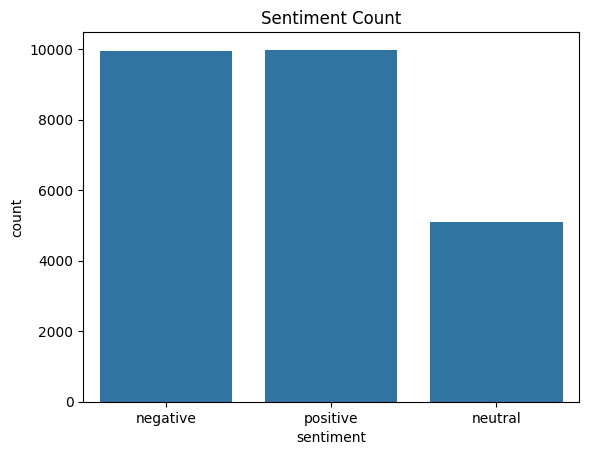

In [ ]:
# count plot

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Count")
plt.show()

In [ ]:
# This chart shows the distribution of customer sentiments (positive, negative, neutral).

# It helps identify which type of sentiment is most common in the dataset.

# A higher number of positive sentiments indicates better customer satisfaction.

# Negative and neutral sentiments highlight areas where improvement is needed

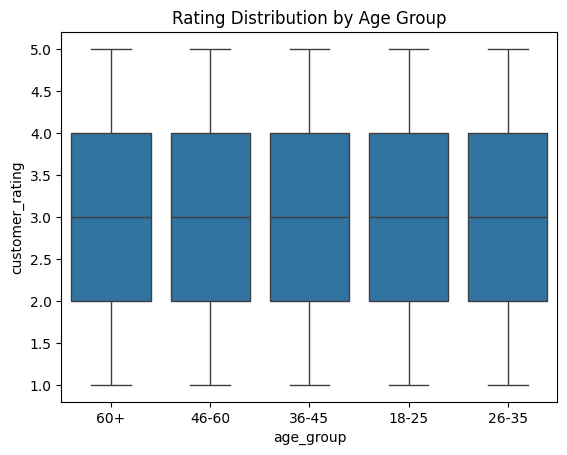

In [ ]:
# Box plot

sns.boxplot(x='age_group', y='customer_rating', data=df)
plt.title("Rating Distribution by Age Group")
plt.show()

In [ ]:
# This box plot visualizes the distribution of customer ratings for different age groups.

# From the plot, it is observed that each age group has a different median rating and spread. The presence of whiskers and possible outliers indicates variability in customer ratings within each group.

# The features used in this chart are age_group and customer_rating.

# This indicates that customer satisfaction varies across age groups and highlights differences in rating patterns and variability.

In [ ]:
Q1 = df['customer_rating'].quantile(0.25)
Q3 = df['customer_rating'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['customer_rating'] >= lower) & (df['customer_rating'] <= upper)]

In [ ]:
# This code performs outlier detection and removal on the customer_rating feature using the Interquartile Range (IQR) method.

# Q1 (25th percentile) and Q3 (75th percentile) are calculated to determine the spread of the data, and the IQR is computed. Based on this, lower and upper limits are defined to identify extreme values.

# Data points that lie outside these limits are considered outliers and are removed from the dataset.

# This helps in improving data quality by eliminating extreme values that could distort analysis and ensures more accurate insights.

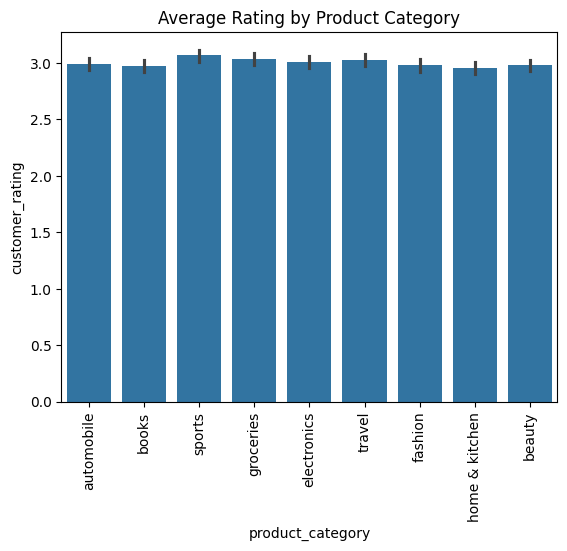

In [ ]:
# Bar plot

sns.barplot(x='product_category', y='customer_rating', data=df)
plt.title("Average Rating by Product Category")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# This bar plot visualizes the average customer rating for each product category.

# From the chart, it is observed that certain product categories have higher average ratings, indicating better customer satisfaction, while others have lower ratings.

# The features used in this chart are product_category and customer_rating.

# This indicates that product category plays an important role in influencing customer ratings and helps identify top-performing and low-performing categories.

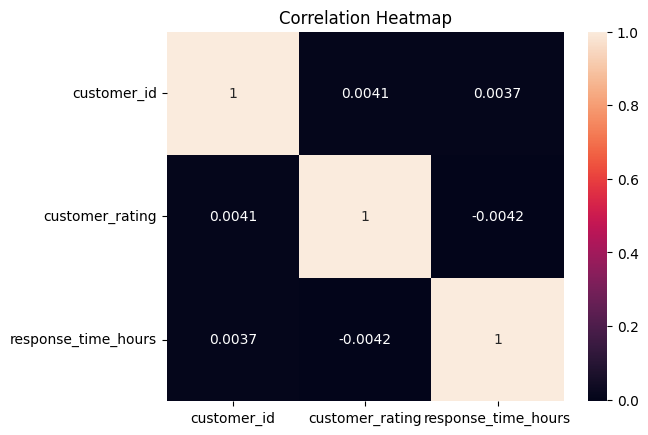

In [ ]:
# correlation
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# This correlation heatmap visualizes the relationships between numerical variables in the dataset.

# From the heatmap, it is observed that some variables show positive correlation, meaning they increase together, while others show negative or weak correlation. The annotated values help in understanding the strength of these relationships.

# The features used in this chart include customer_rating and response_time_hours.

# This indicates the degree of association between variables and helps in identifying key factors that may influence customer ratings.

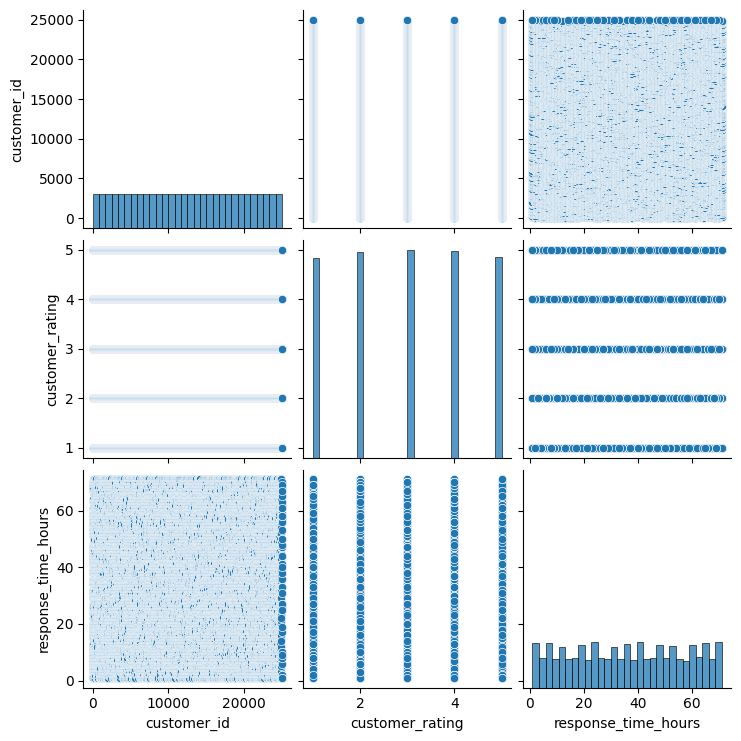

In [ ]:
# Pair plot

sns.pairplot(df)
plt.show()

In [ ]:
# This pair plot shows the pairwise relationships between all numerical features in the dataset.

# From the plot, it is observed that the diagonal represents the distribution of individual variables, while the scatter plots show relationships between pairs of variables. Some variable pairs may show positive or negative correlation, while others show no clear relationship.

# The features used in this chart include numerical variables such as customer_rating and response_time_hours.

# This indicates the presence or absence of relationships between variables and helps in identifying patterns, trends, and potential correlations in the dataset.

In [ ]:
# GroupBy

df.groupby('sentiment')['customer_rating'].agg(['mean','min','max','count'])

,mean,min,max,count
sentiment,,,,
negative,1.507799,1,2,9937
neutral,3.000000,3,3,5085
positive,4.492283,4,5,9978


In [ ]:
# This analysis groups customer ratings based on sentiment and computes key statistical measures including mean, minimum, maximum, and count.

# From the result, it is observed that positive sentiment generally has higher average ratings, while negative sentiment shows lower ratings. The minimum and maximum values indicate the range of ratings within each sentiment, and the count shows the number of observations.

# The features used in this analysis are sentiment and customer_rating.

# This indicates that sentiment has a strong impact on customer ratings and helps in understanding the spread and distribution of ratings across different sentiment categories.

In [ ]:
df.groupby('product_category')['customer_rating'].mean()

,customer_rating
product_category,
automobile,2.987999
beauty,2.978810
books,2.976174
electronics,3.010275
fashion,2.980230
groceries,3.034990
home & kitchen,2.957814
sports,3.066594
travel,3.027748


In [ ]:
# This analysis computes the mean customer rating for each product category using the groupby function.

# From the result, it is observed that certain product categories have higher average ratings, indicating better customer satisfaction, while others have lower ratings.

# The features used in this analysis are product_category and customer_rating.

# This indicates that customer satisfaction varies across product categories and helps identify which categories perform better.

In [ ]:
# Crosstab
pd.crosstab(df['sentiment'], df['product_category'])

product_category,automobile,beauty,books,electronics,fashion,groceries,home & kitchen,sports,travel
sentiment,,,,,,,,,
negative,1126,1104,1141,1061,1148,1108,1134,1049,1066
neutral,583,537,583,545,534,585,533,553,632
positive,1124,1049,1088,1119,1100,1165,1059,1161,1113


In [ ]:
# This crosstab represents the count of observations for each combination of sentiment and product category.

# From the table, it is observed that certain product categories have a higher number of positive sentiments, while others may have more negative or neutral sentiments.

# The features used in this table are sentiment and product_category.

# This indicates that customer sentiment varies across product categories and helps in identifying categories with better or poorer customer feedback.

In [ ]:
# Pivot table

pd.pivot_table(df,
               values='customer_rating',
               index='sentiment',
               columns='product_category',
               aggfunc=['mean','count'])

mean                                            \
product_category automobile    beauty     books electronics   fashion   
sentiment                                                               
negative           1.491119  1.520833  1.521472    1.508954  1.498258   
neutral            3.000000  3.000000  3.000000    3.000000  3.000000   
positive           4.481317  4.502383  4.488971    4.438785  4.517273   

                                                                   count  \
product_category groceries home & kitchen    sports    travel automobile   
sentiment                                                                  
negative          1.499097       1.507937  1.513823  1.509381       1126   
neutral           3.000000       3.000000  3.000000  3.000000        583   
positive          4.513305       4.489141  4.501292  4.497754       1124   

                                                                            \
product_category beauty books electronics fashion groceries home & kitchen   
sentiment                                                                    
negative           1104  1141        1061    1148      1108           1134   
neutral             537   583         545     534       585            533   
positive           1049  1088        1119    1100      1165           1059   

                                
product_category sports travel  
sentiment                       
negative           1049   1066  
neutral             553    632  
positive           1161   1113

In [ ]:
# This pivot table presents the mean and count of customer ratings grouped by sentiment and product category.

#From the table, it is observed that certain product categories receive higher average ratings under positive sentiment, while others may have lower ratings under negative sentiment. The count also shows how many observations are present in each category.

# The features used in this table are sentiment, product_category, and customer_rating.

# This indicates that both sentiment and product category play a significant role in determining customer ratings, and the data distribution varies across categories.

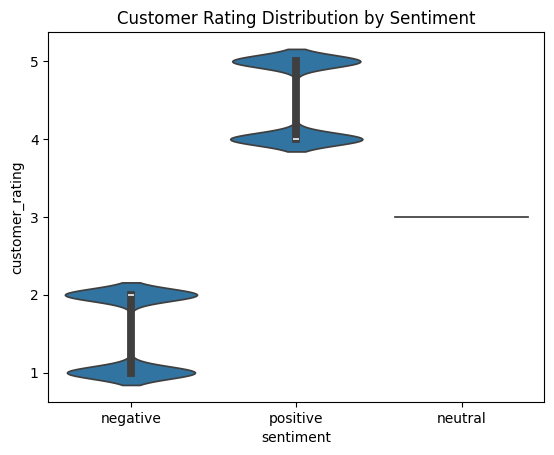

In [ ]:
# Advanced plot - Violin plot

sns.violinplot(x=df["sentiment"], y=df["customer_rating"])

plt.title("Customer Rating Distribution by Sentiment")
plt.show()

In [ ]:
# This is a violin plot used to visualize the distribution of customer ratings across different sentiment categories.

# From the plot, it is observed that customers with positive sentiment tend to give higher ratings, while customers with negative sentiment give lower ratings.

# The features used in this chart are sentiment and customer_rating.

# This indicates that customer sentiment has a strong impact on the ratings given by customers.

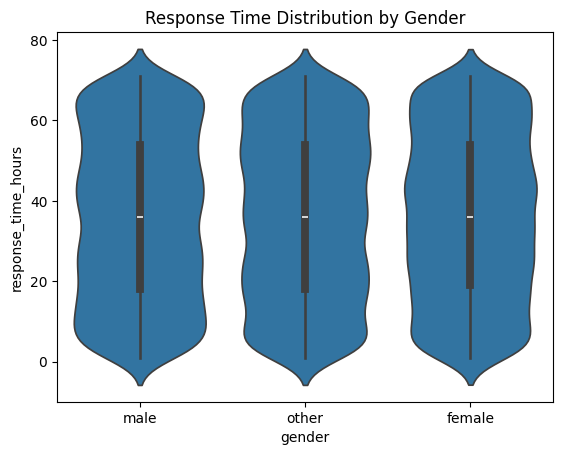

In [ ]:
sns.violinplot(x=df["gender"], y=df["response_time_hours"])

plt.title("Response Time Distribution by Gender")
plt.show()

In [ ]:
 #This is a violin plot used to visualize the distribution of response time across different gender categories.

# From the plot, it is observed that there is variation in response time among different genders, with some categories showing wider spread indicating inconsistency.

# The features used in this chart are gender and response_time_hours.

# This indicates that response time is not uniform and may vary depending on gender categories.

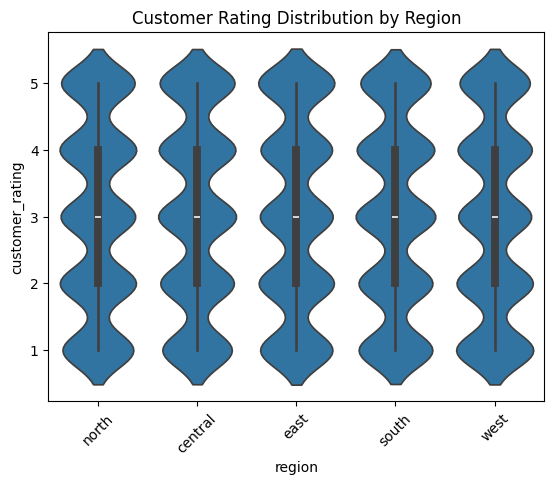

In [ ]:
sns.violinplot(x=df["region"], y=df["customer_rating"])

plt.title("Customer Rating Distribution by Region")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# This is a violin plot used to visualize the distribution of customer ratings across different regions.

# From the plot, it is observed that some regions have more consistent ratings while others show a wider distribution, indicating variability in customer satisfaction.

# The features used in this chart are region and customer_rating.

# This indicates that customer experience is not uniform and varies across different regions.

## Stage 4 – Documentation, Insights and Presentation

Show a dashboard aligning all the charts in powerbi by connecting python in PowerBI

Summarize findings in plain English (what do the patterns mean)

Highlight 3–5 key insights (trends, anomalies, correlations)

Provide recommendations for business or decision-making

Explain the FINAL STORY WITH THE DASHBOARD

Create a PDF pasting your DASHBOARD, explaining all the above mentioned concepts and submit it


https://drive.google.com/file/d/16oMl0-htUisc8VbUtNHXzwDBExRGj-fD/view?usp=sharing